In [1]:
# from sentence_transformers import SentenceTransformer
import gensim.downloader as api

word_vectors = api.load("glove-wiki-gigaword-100")


In [8]:
import numpy as np

sentence = "She deposited money in the bank women bulldozer"

tokens = sentence.lower().split()

embeddings = []
valid_tokens = []

for token in tokens:
    if token in word_vectors:
        embeddings.append(word_vectors[token])
        valid_tokens.append(token)

embeddings = np.array(embeddings)

embeddings.shape


(8, 100)

In [6]:
embeddings[0][:3]

array([0.31436, 0.15312, 0.18259], dtype=float32)

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

pca = PCA(n_components=3)
embeddings_3d = pca.fit_transform(embeddings)
embeddings_3d = normalize(embeddings_3d)


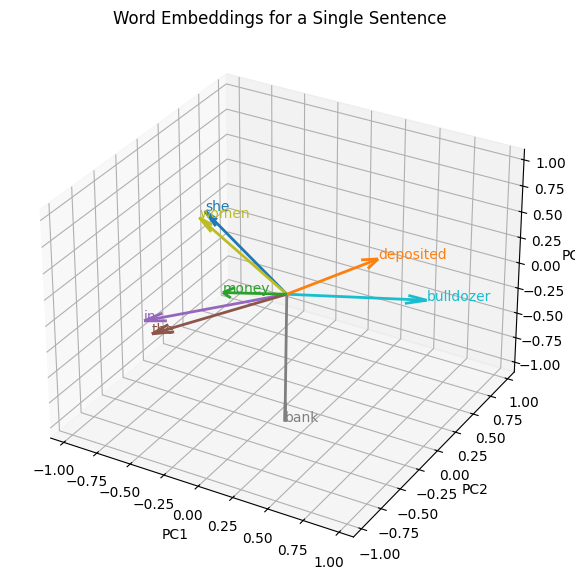

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

colors = plt.cm.tab10(np.linspace(0, 1, len(valid_tokens)))

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

for i, word in enumerate(valid_tokens):
    ax.quiver(
        0, 0, 0,
        embeddings_3d[i,0],
        embeddings_3d[i,1],
        embeddings_3d[i,2],
        color=colors[i],
        arrow_length_ratio=0.15,
        linewidth=2
    )
    ax.text(
        embeddings_3d[i,0],
        embeddings_3d[i,1],
        embeddings_3d[i,2],
        word,
        fontsize=10,
        color=colors[i]
    )

ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.set_zlim([-1.1, 1.1])

ax.set_title("Word Embeddings for a Single Sentence")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()
